<a href="https://colab.research.google.com/github/smozwald/foundation-flood/blob/main/notebooks/02_database_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Database Exploration

Having created our database by downloading and logging flood events with the Dartmouth Flood Observatory, we want to select the rivers to use, and explore some samples in Google Earth Engine. This must include the following steps in each cell

1. Connect to Supabase, provide summary of rivers. We will make a regional model, and so should look at dividing into major regions. We want to calculate the following data(First per Country, second per Continent in two seperate adjacent cells):
a. Total Rivers Per Country/Continent
c. Total Flood Events Per Country/Continent (also total flood events of each of the 5 categories per continent
d. Percentage of Rivers per Country/Continent with >15 total events. (These are likely erroneous).

2. As above, per continent.

3. Visualization of Rivers in user-defined continent/country (Text input at top of cell). Select up to 4 rivers, show flood discharge graph from 2015, with lines indicating cutoff on y-axis for flood categories. Ideally first 2 should have <15 total events, and second >15 total events so we can assess the issues. X-axis represents time, shaded grey in period of flood (for each event in flood_events, start_date and end_date indicate this). Shade of grey goes from light grey for category 1 to dark grey for category 5. Ensure legend.

In [2]:
# CELL 1 — Install dependencies

# %%
!pip install psycopg2-binary python-dotenv reverse_geocoder pycountry-convert pandas matplotlib
!pip install earthengine-api shapely


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 18.6 MB/s eta 0:00:00
  Created wheel for reverse_geocoder: filename=reverse_geocoder-1.5.1-py3-none-any.whl size=2268067 sha256=528d664b9ac4ce4d346ce06c7bbd40cab4b45e9a44941c71895a6b32ed62efb5
  Stored in directory: /root/.cache/pip/wheels/11/e1/67/6e47f0ad41ea1843d37e1fbe79c6074744a1f4aace641cf800
Successfully built reverse_geocoder


In [3]:
# @title
# CELL 2 — Imports, DB connection, load stations with country/continent

# %%
import os
import psycopg2
import pandas as pd
import reverse_geocoder as rg
import pycountry_convert as pc
from dotenv import load_dotenv
from google.colab import userdata

# Retrieve the secret value
CONN_STRING = userdata.get('SUPABASE_CONN_STRING')

load_dotenv()

# Load all stations with lat/lon from PostGIS geometry
with psycopg2.connect(CONN_STRING) as conn:
    stations_df = pd.read_sql("""
        SELECT
            station_id,
            dfo_station_id,
            station_name,
            ST_Y(geom::geometry) AS lat,
            ST_X(geom::geometry) AS lon
        FROM discharge_stations
    """, conn)

# Derive country and continent from coordinates
coords = list(zip(stations_df["lat"], stations_df["lon"]))
geo_results = rg.search(coords, verbose=False)
stations_df["country_code"] = [r["cc"] for r in geo_results]
stations_df["country"]      = [r["name"].split(",")[-1].strip() for r in geo_results]

# Use country name from pycountry_convert for consistency
def cc_to_country(cc):
    try:
        return pc.country_alpha2_to_country_name(cc)
    except Exception:
        return cc

def cc_to_continent(cc):
    try:
        cont_code = pc.country_alpha2_to_continent_code(cc)
        return pc.convert_continent_code_to_continent_name(cont_code)
    except Exception:
        return "Unknown"

stations_df["country"]   = stations_df["country_code"].apply(cc_to_country)
stations_df["continent"] = stations_df["country_code"].apply(cc_to_continent)

print(f"Loaded {len(stations_df)} stations across "
      f"{stations_df['country'].nunique()} countries, "
      f"{stations_df['continent'].nunique()} continents")
print(stations_df[["station_name", "country", "continent"]].head())


/tmp/ipykernel_2235/1467378956.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stations_df = pd.read_sql("""


Loaded 335 stations across 58 countries, 6 continents
    station_name   country continent
0          Indus  Pakistan      Asia
1          Indus  Pakistan      Asia
2          Indus  Pakistan      Asia
3  IrrawaddyTrib   Myanmar      Asia
4        Ghaghra     India      Asia


In [4]:
# @title
# CELL 3 — Load flood event counts per station

# %%
with psycopg2.connect(CONN_STRING) as conn:
    events_df = pd.read_sql("""
        SELECT
            station_id,
            max_category,
            COUNT(*) AS event_count
        FROM flood_events
        WHERE detection_method = 'threshold_exceedance_7d'
        GROUP BY station_id, max_category
    """, conn)

# Total events per station
total_events = (
    events_df.groupby("station_id")["event_count"]
    .sum()
    .rename("total_events")
    .reset_index()
)

# Events per category per station (pivoted)
events_pivot = (
    events_df.pivot_table(
        index="station_id", columns="max_category",
        values="event_count", aggfunc="sum", fill_value=0
    )
    .rename(columns={c: f"cat{c}_events" for c in range(1, 6)})
    .reset_index()
)

stations_full = (
    stations_df
    .merge(total_events,  on="station_id", how="left")
    .merge(events_pivot,  on="station_id", how="left")
    .fillna(0)
)
for col in ["total_events"] + [f"cat{c}_events" for c in range(1, 6)]:
    stations_full[col] = stations_full[col].astype(int)

print(stations_full[["station_name", "country", "continent", "total_events"]].head())


/tmp/ipykernel_2235/3065164216.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events_df = pd.read_sql("""


    station_name   country continent  total_events
0          Indus  Pakistan      Asia            14
1          Indus  Pakistan      Asia             8
2          Indus  Pakistan      Asia            11
3  IrrawaddyTrib   Myanmar      Asia             4
4        Ghaghra     India      Asia             5


In [5]:
# @title
# CELL 4 — Summary per Country
# ============================================================

# %%
cat_cols = [f"cat{c}_events" for c in range(1, 6)]

country_summary = (
    stations_full
    .groupby("country")
    .agg(
        total_rivers        = ("station_id",    "count"),
        total_flood_events  = ("total_events",  "sum"),
        rivers_gt15_events  = ("total_events",  lambda x: (x > 15).sum()),
        **{col: (col, "sum") for col in cat_cols},
    )
    .reset_index()
)
country_summary["pct_rivers_gt15_events"] = (
    (country_summary["rivers_gt15_events"] / country_summary["total_rivers"] * 100)
    .round(1)
)
country_summary = country_summary.sort_values("total_rivers", ascending=False)

print("=== Per Country ===")
display_cols = ["country", "total_rivers", "total_flood_events"] + cat_cols + ["pct_rivers_gt15_events"]
print(country_summary[display_cols].to_string(index=False))


=== Per Country ===
                              country  total_rivers  total_flood_events  cat1_events  cat2_events  cat3_events  cat4_events  cat5_events  pct_rivers_gt15_events
                                India            32                 421          285           86           43            2            5                    18.8
                               Brazil            27                 543          391           84           50           11            7                    55.6
                        United States            26                 284          217           41           17            3            6                    19.2
                             Colombia            25                 404          330           40           17            9            8                    20.0
      Bolivia, Plurinational State of            18                 320          264           36           14            4            2                    22.2
              

In [6]:
# @title
# CELL 5 — Summary per Continent
# ============================================================

# %%
continent_summary = (
    stations_full
    .groupby("continent")
    .agg(
        total_rivers        = ("station_id",    "count"),
        total_flood_events  = ("total_events",  "sum"),
        rivers_gt15_events  = ("total_events",  lambda x: (x > 15).sum()),
        **{col: (col, "sum") for col in cat_cols},
    )
    .reset_index()
)
continent_summary["pct_rivers_gt15_events"] = (
    (continent_summary["rivers_gt15_events"] / continent_summary["total_rivers"] * 100)
    .round(1)
)
continent_summary = continent_summary.sort_values("total_rivers", ascending=False)

print("=== Per Continent ===")
display_cols = ["continent", "total_rivers", "total_flood_events"] + cat_cols + ["pct_rivers_gt15_events"]
print(continent_summary[display_cols].to_string(index=False))


=== Per Continent ===
    continent  total_rivers  total_flood_events  cat1_events  cat2_events  cat3_events  cat4_events  cat5_events  pct_rivers_gt15_events
South America           104                1745         1323          203          116           35           68                    32.7
         Asia           100                1323          940          213           99           16           55                    25.0
       Africa            57                 725          510           99           76           16           24                    31.6
North America            38                 463          356           68           26            7            6                    18.4
       Europe            25                 172          111           41           13            4            3                     4.0
      Oceania            11                  93           60           18           11            1            3                     9.1


In [7]:
#CELL 6 - PRELUDE - SELECT REGION AND REGION_TYPE
REGION_TYPE = "country"   # 'continent' or 'country'
REGION_NAME = "Pakistan"        # e.g. 'Asia', 'South America', 'Australia', 'India'


Selected stations for country='Pakistan':
station_name  country  total_events
       Indus Pakistan            14
       Indus Pakistan             8
       Indus Pakistan            11
      Chenab Pakistan             7
       Indus Pakistan             8
      Chenab Pakistan             6
       Indus Pakistan             8
        Ravi Pakistan             5
 Indus Delta Pakistan            10
        None Pakistan            13
       Indus Pakistan            25


/tmp/ipykernel_2235/324905013.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ts_df = pd.read_sql("""
/tmp/ipykernel_2235/324905013.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  thresh_df = pd.read_sql("""
/tmp/ipykernel_2235/324905013.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fevents_df = pd.read_sql("""


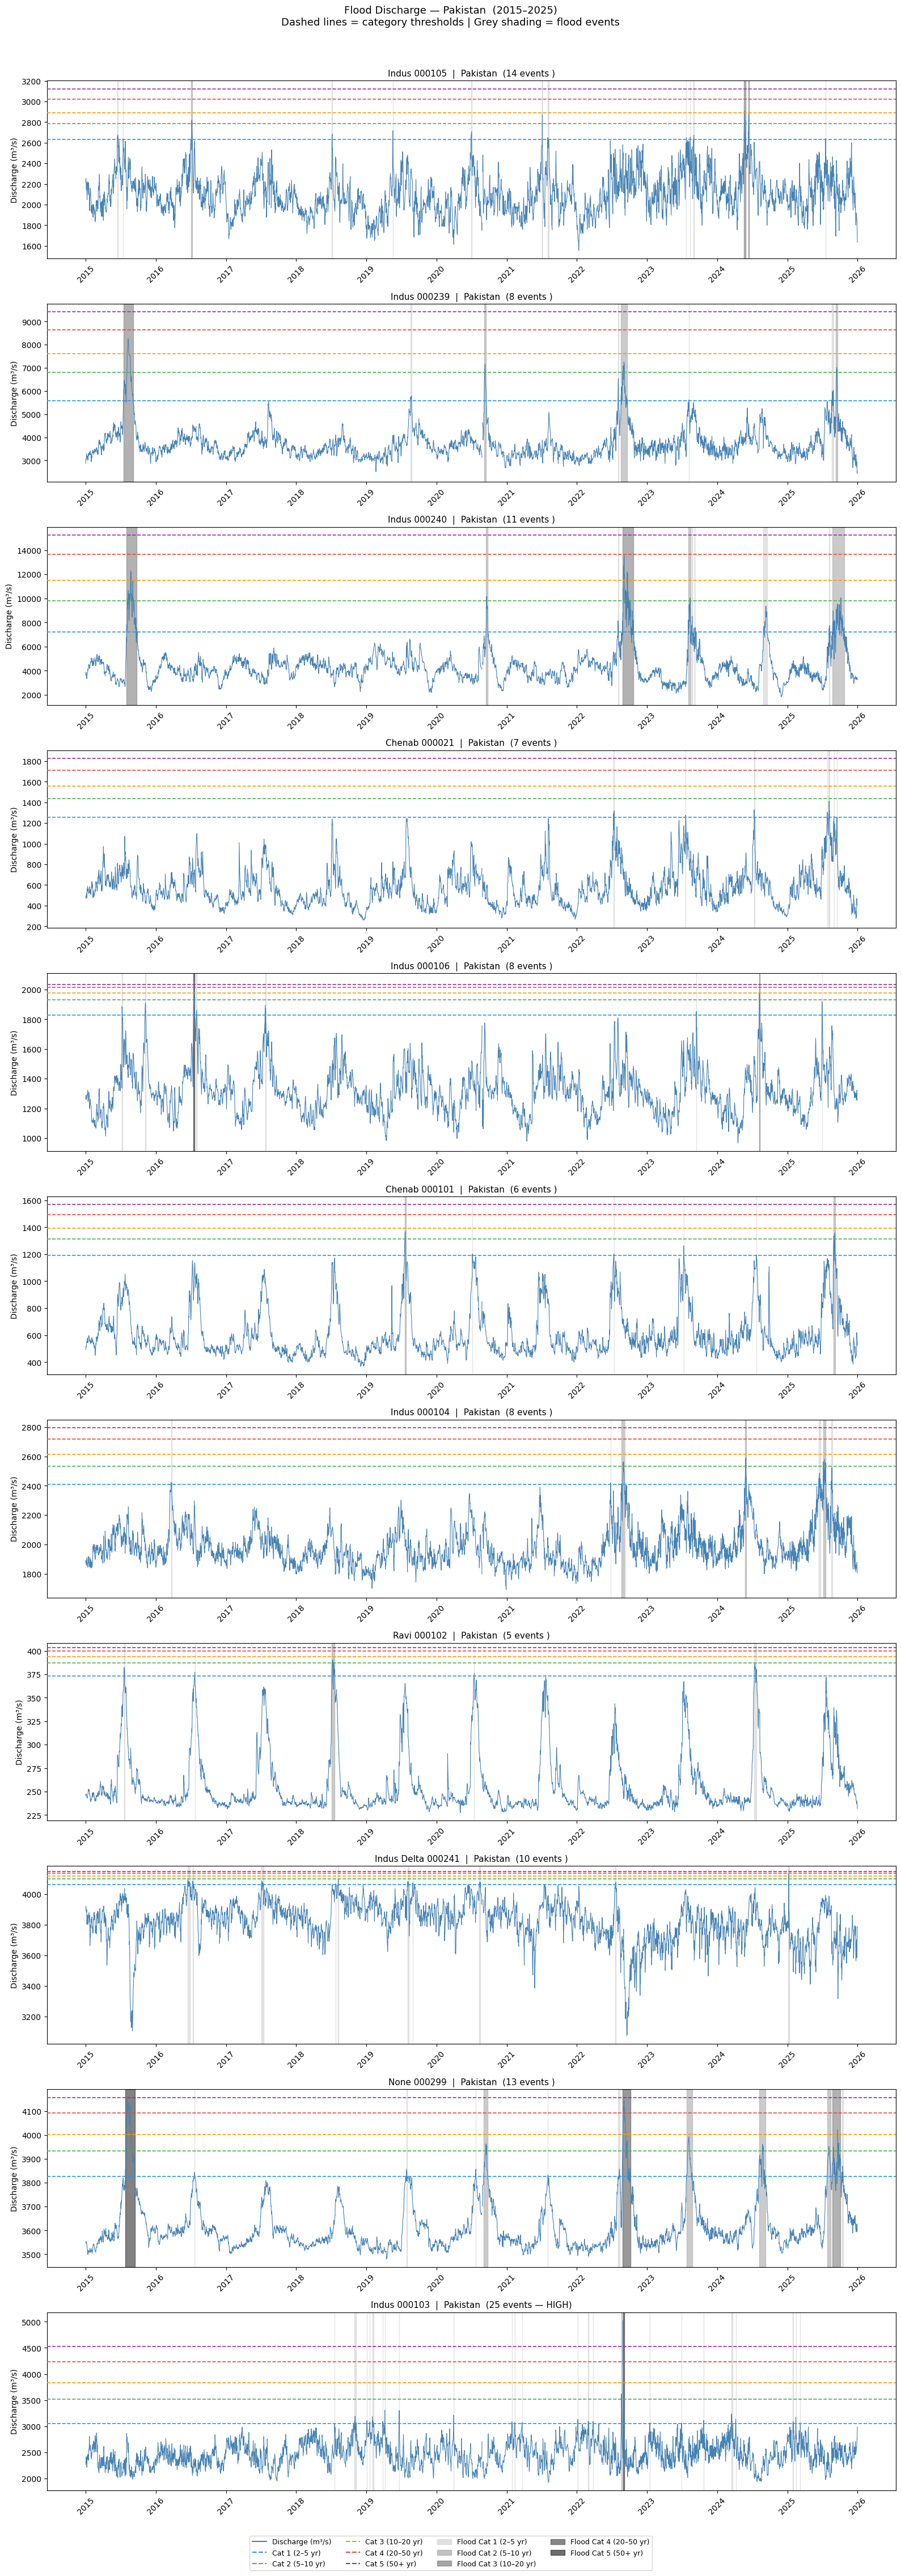

In [8]:
# @title

# %%
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

assert REGION_TYPE in ("continent", "country"), "REGION_TYPE must be 'continent' or 'country'"

region_stations = stations_full[stations_full[REGION_TYPE] == REGION_NAME].copy()
if region_stations.empty:
    raise ValueError(f"No stations found for {REGION_TYPE}='{REGION_NAME}'. "
                     f"Available: {sorted(stations_full[REGION_TYPE].unique())}")

# Select up to 2 stations with <=15 total events, then up to 2 with >15
low_event  = region_stations[region_stations["total_events"] <= 15].head(10)
high_event = region_stations[region_stations["total_events"] >  15].head(4)
selected   = pd.concat([low_event, high_event]).head(20)
station_ids = selected["station_id"].tolist()

print(f"Selected stations for {REGION_TYPE}='{REGION_NAME}':")
print(selected[["station_name", "country", "total_events"]].to_string(index=False))

# Load discharge time series (2015 onwards)
with psycopg2.connect(CONN_STRING) as conn:
    ts_df = pd.read_sql("""
        SELECT station_id, obs_date, discharge_m3s
        FROM discharge_ts
        WHERE station_id = ANY(%(ids)s::uuid[])
          AND obs_date >= '2015-01-01'
        ORDER BY station_id, obs_date
    """, conn, params={"ids": station_ids})

    # Load flood thresholds for selected stations
    thresh_df = pd.read_sql("""
        SELECT station_id, category, discharge_threshold_m3s
        FROM flood_thresholds
        WHERE station_id = ANY(%(ids)s::uuid[])
        ORDER BY station_id, category
    """, conn, params={"ids": station_ids})

    # Load flood events for selected stations (2015 onwards)
    fevents_df = pd.read_sql("""
        SELECT station_id, flood_start, flood_end, max_category
        FROM flood_events
        WHERE station_id = ANY(%(ids)s::uuid[])
          AND flood_start >= '2015-01-01'
          AND detection_method = 'threshold_exceedance_7d'
        ORDER BY station_id, flood_start
    """, conn, params={"ids": station_ids})

ts_df["obs_date"]         = pd.to_datetime(ts_df["obs_date"])
fevents_df["flood_start"] = pd.to_datetime(fevents_df["flood_start"])
fevents_df["flood_end"]   = pd.to_datetime(fevents_df["flood_end"])

# Colour maps
THRESHOLD_COLORS = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800", 4: "#F44336", 5: "#9C27B0"}
FLOOD_GREYS      = {1: "#D3D3D3", 2: "#A9A9A9", 3: "#808080", 4: "#555555", 5: "#2F2F2F"}
CAT_LABELS       = {
    1: "Cat 1 (2–5 yr)",
    2: "Cat 2 (5–10 yr)",
    3: "Cat 3 (10–20 yr)",
    4: "Cat 4 (20–50 yr)",
    5: "Cat 5 (50+ yr)",
}

n = len(station_ids)
fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, sid in zip(axes, station_ids):
    row   = selected[selected["station_id"] == sid].iloc[0]
    ts    = ts_df[ts_df["station_id"] == sid].copy()
    evts  = fevents_df[fevents_df["station_id"] == sid].copy()
    thrsh = thresh_df[thresh_df["station_id"] == sid].copy()

    # Shade flood event periods
    for _, ev in evts.iterrows():
        ax.axvspan(ev["flood_start"], ev["flood_end"],
                   color=FLOOD_GREYS.get(ev["max_category"], "#808080"),
                   alpha=0.6, zorder=1)

    # Discharge line
    ax.plot(ts["obs_date"], ts["discharge_m3s"],
            color="steelblue", linewidth=0.8, zorder=2, label="Discharge (m³/s)")

    # Category threshold lines
    for _, tr in thrsh.iterrows():
        cat = int(tr["category"])
        ax.axhline(tr["discharge_threshold_m3s"],
                   color=THRESHOLD_COLORS.get(cat, "black"),
                   linewidth=1.2, linestyle="--", zorder=3)

    event_flag = f"({row['total_events']} events {'— HIGH' if row['total_events'] > 15 else ''})"
    ax.set_title(f"{row['station_name']} {row['dfo_station_id']}  |  {row['country']}  {event_flag}", fontsize=11)
    ax.set_ylabel("Discharge (m³/s)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=45)

# Shared legend
threshold_handles = [
    Line2D([0], [0], color=THRESHOLD_COLORS[c], linewidth=1.5,
           linestyle="--", label=CAT_LABELS[c])
    for c in range(1, 6)
]
flood_handles = [
    mpatches.Patch(color=FLOOD_GREYS[c], alpha=0.7, label=f"Flood {CAT_LABELS[c]}")
    for c in range(1, 6)
]
discharge_handle = Line2D([0], [0], color="steelblue", linewidth=1.5, label="Discharge (m³/s)")

fig.legend(
    handles=[discharge_handle] + threshold_handles + flood_handles,
    loc="lower center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True,
)

fig.suptitle(
    f"Flood Discharge — {REGION_NAME}  (2015–2025)\n"
    f"Dashed lines = category thresholds | Grey shading = flood events",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


# Pakistan as a First Case

Based on the DFO records, we have quite a few instances of Floods in Pakistan which were catastrophic to various levels. It is interesting to see if we can assess how well we can tell the risk levels of different pixels prior to flooding. We will move on to this in a first exploration on GEE.

The one station with anomalous values (>15 flood events in record since 2015), appears to be due to a long term change in the average discharge rate around the 2000s. We will exclude it from results

In [9]:
# @title
# ============================================================
# CELL 7 — Rivers (HydroSHEDS via GEE)
# ============================================================

# %%
import sys
import uuid
import json
import psycopg2
import ee
from shapely.geometry import shape

TEST = '--test' in sys.argv

pak_stations = stations_full[
    (stations_full['country'] == 'Pakistan') &
    (stations_full['dfo_station_id'] != '000103')
].copy().reset_index(drop=True)

if TEST:
    pak_stations = pak_stations.head(1)

print(f"TEST={TEST} | Processing {len(pak_stations)} Pakistan stations")

ee.Authenticate()
ee.Initialize(project='foundation-flood')

rivers_fc = ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers')

# --- NEW: Ensure HydroSHEDS data source record exists ---
HYDROSHEDS_SOURCE_ID = str(uuid.uuid5(
    uuid.NAMESPACE_DNS, "WWF HydroSHEDS Free-Flowing Rivers v1"
))

with psycopg2.connect(CONN_STRING) as conn:
    with conn.cursor() as cur:
        cur.execute("""
            INSERT INTO data_sources (source_id, product_name, methodology_desc, version_tag)
            VALUES (
                %(source_id)s::uuid,
                'WWF HydroSHEDS Free-Flowing Rivers',
                'HydroSHEDS Free-Flowing Rivers derived from WWF/HydroSHEDS v1 via Google Earth Engine. '
                'River segments selected by maximum upstream area (UPLAND_SKM) within 5 km of station, '
                'clipped to 50 km buffer.',
                'v1'
            )
            ON CONFLICT (product_name) DO NOTHING
            RETURNING source_id
        """, {'source_id': HYDROSHEDS_SOURCE_ID})

        row = cur.fetchone()
        if row:
            HYDROSHEDS_SOURCE_ID = str(row[0])  # freshly inserted
        else:
            # Row already existed — fetch the real source_id
            cur.execute("""
                SELECT source_id FROM data_sources
                WHERE product_name = 'WWF HydroSHEDS Free-Flowing Rivers'
            """)
            HYDROSHEDS_SOURCE_ID = str(cur.fetchone()[0])

        conn.commit()

print(f"HydroSHEDS source_id: {HYDROSHEDS_SOURCE_ID}")
# ---------------------------------------------------------

matched_rows = []

with psycopg2.connect(CONN_STRING) as conn:
    with conn.cursor() as cur:
        for _, srow in pak_stations.iterrows():
            station_id = str(srow['station_id'])
            st_name = srow['station_name'] or "Unknown Station"
            point = ee.Geometry.Point([float(srow['lon']), float(srow['lat'])])

            # Increase search radius to 5km to catch offset river lines
            search_area = point.buffer(5000)
            buf_50km = point.buffer(50000)

            nearby = rivers_fc.filterBounds(search_area)

            if nearby.size().getInfo() == 0:
                print(f"  WARN: no HydroSHEDS match within 5 km for {st_name}, skipping")
                continue

            # Select the main channel based on upstream area
            segment = nearby.sort('UPLAND_SKM', False).first()
            props = segment.getInfo()['properties']

            # IMPROVED NAMING LOGIC
            # 1. English Name -> 2. Local Name -> 3. Station Name -> 4. Fallback
            river_name = (
                props.get('RIV_NAME_EN') or
                props.get('RIV_NAME') or
                (f"{st_name} River" if st_name and st_name != 'None' else None) or
                f"River_{props.get('MAIN_RIV', 'Unknown')}"
            )

            clipped_geojson = segment.geometry().intersection(buf_50km).getInfo()
            shp = shape(clipped_geojson)

            if shp.is_empty:
                continue

            if hasattr(shp, 'geoms'):
                shp = max(shp.geoms, key=lambda g: g.length)

            river_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"hydrosheds_{station_id}"))

            # SQL execution remains similar, but now with cleaner names
            cur.execute("""
                INSERT INTO rivers (river_id, river_name, geom, river_source_metadata_id)
                VALUES (%(river_id)s::uuid, %(river_name)s, ST_GeomFromText(%(wkt)s, 4326), %(source_id)s)
                ON CONFLICT (river_id) DO UPDATE
                SET river_name = EXCLUDED.river_name, geom = EXCLUDED.geom
            """, {
                'river_id': river_id,
                'river_name': river_name,
                'wkt': shp.wkt,
                'source_id': HYDROSHEDS_SOURCE_ID,
            })

            # Update discharge_stations link
            cur.execute("""
                UPDATE discharge_stations
                   SET river_id = %(river_id)s::uuid
                 WHERE station_id = %(station_id)s::uuid
            """, {'river_id': river_id, 'station_id': station_id})
                        # Inside the for loop, after the UPDATE discharge_stations and conn.commit():
            matched_rows.append({
                'station_id':    station_id,
                'dfo_station_id': srow['dfo_station_id'],
                'river_id':      river_id,
                'station_name':  st_name,
                'river_name':    river_name,
            })
            conn.commit()
            print(f"  Matched: {st_name} -> {river_name}")

matched_df = pd.DataFrame(matched_rows)
print(f"\nDone: {len(matched_df)}/{len(pak_stations)} stations matched to rivers")


TEST=False | Processing 13 Pakistan stations
HydroSHEDS source_id: aeddea49-f96d-40a7-bff0-4be227d81946
  Matched: Indus -> Indus River
  Matched: Indus -> Indus River
  Matched: Indus -> Indus River
  Matched: Chenab -> Chenab River
  Matched: Indus -> Indus River
  Matched: Chenab -> Chenab River
  Matched: Indus -> Indus River
  Matched: Ravi -> Ravi River
  Matched: Indus Delta -> Indus Delta River
  Matched: None -> River_Unknown
  Matched: Chenab -> Chenab River
  Matched: Jhelum -> Jhelum River
  Matched: None -> River_Unknown

Done: 13/13 stations matched to rivers


In [10]:
matched_df = pd.DataFrame(matched_rows)
print(f"\nDone: {len(matched_df)}/{len(pak_stations)} stations matched to rivers")


Done: 13/13 stations matched to rivers


In [30]:
# ============================================================
# CELL 8 — Study zones (configurable buffer centred on station)
# ============================================================
# Set ZONE_SIZE_M and ZONE_SET_NAME below, then run.
# Creates a square envelope of ZONE_SIZE_M x ZONE_SIZE_M
# centred on each matched station, in UTM zone 42N (EPSG:32642).
# ============================================================
# %%

# ── User config ───────────────────────────────────────────────────────────────
ZONE_SIZE_M   = 10_000          # full side length in metres (e.g. 10000 = 10×10 km)
ZONE_SET_NAME = 'initial'       # zone_set label (e.g. 'initial', '1km', '10km')
# ─────────────────────────────────────────────────────────────────────────────

half = ZONE_SIZE_M / 2
zone_label = f"{ZONE_SIZE_M // 1000}km" if ZONE_SIZE_M >= 1000 else f"{ZONE_SIZE_M}m"

print(f"Zone size  : {ZONE_SIZE_M:,} m  ({zone_label} square)")
print(f"Zone set   : '{ZONE_SET_NAME}'")
print(f"Stations   : {len(matched_df)}")
print()

with psycopg2.connect(CONN_STRING) as conn:
    with conn.cursor() as cur:
        for _, mrow in matched_df.iterrows():
            station_id = mrow['station_id']
            river_id   = mrow['river_id']
            zone_id    = f"{mrow['dfo_station_id']}_{ZONE_SET_NAME}"

            cur.execute("""
                INSERT INTO study_zones (
                    zone_id, station_id, river_id,
                    geom, centroid,
                    zone_set, position, zone_size_m,
                    generation_method, distance_m_along_river
                )
                SELECT
                    %(zone_id)s,
                    %(station_id)s::uuid,
                    %(river_id)s::uuid,
                    ST_Transform(
                        ST_MakeEnvelope(
                            ST_X(ST_Transform(ds.geom::geometry, 32642)) - %(half)s,
                            ST_Y(ST_Transform(ds.geom::geometry, 32642)) - %(half)s,
                            ST_X(ST_Transform(ds.geom::geometry, 32642)) + %(half)s,
                            ST_Y(ST_Transform(ds.geom::geometry, 32642)) + %(half)s,
                            32642
                        ),
                        4326
                    ),
                    ds.geom::geometry,
                    %(zone_set)s,
                    0,
                    %(zone_size_m)s,
                    'centred_on_station',
                    ST_LineLocatePoint(r.geom::geometry,
                        ST_ClosestPoint(r.geom::geometry, ds.geom::geometry))
                    * ST_Length(r.geom::geography)
                FROM discharge_stations ds, rivers r
                WHERE ds.station_id = %(station_id)s::uuid
                  AND r.river_id    = %(river_id)s::uuid
                ON CONFLICT (zone_id) DO UPDATE
                    SET geom                   = EXCLUDED.geom,
                        centroid               = EXCLUDED.centroid,
                        zone_set               = EXCLUDED.zone_set,
                        zone_size_m            = EXCLUDED.zone_size_m,
                        distance_m_along_river = EXCLUDED.distance_m_along_river
            """, {
                'zone_id':    zone_id,
                'station_id': str(station_id),
                'river_id':   str(river_id),
                'half':       half,
                'zone_set':   ZONE_SET_NAME,
                'zone_size_m': ZONE_SIZE_M,
            })
            print(f"  Upserted: {zone_id}  ({zone_label} square, zone_set='{ZONE_SET_NAME}')")

    conn.commit()

print(f"\nDone: {len(matched_df)} zones written to study_zones")
print(f"Verify with: SELECT zone_id, zone_set, ST_Area(geom::geography)/1e6 AS km2 "
      f"FROM study_zones WHERE zone_set = '{ZONE_SET_NAME}'")

Zone size  : 10,000 m  (10km square)
Zone set   : 'initial'
Stations   : 13

  Upserted: 000105_initial  (10km square, zone_set='initial')
  Upserted: 000239_initial  (10km square, zone_set='initial')
  Upserted: 000240_initial  (10km square, zone_set='initial')
  Upserted: 000021_initial  (10km square, zone_set='initial')
  Upserted: 000106_initial  (10km square, zone_set='initial')
  Upserted: 000101_initial  (10km square, zone_set='initial')
  Upserted: 000104_initial  (10km square, zone_set='initial')
  Upserted: 000102_initial  (10km square, zone_set='initial')
  Upserted: 000241_initial  (10km square, zone_set='initial')
  Upserted: 000299_initial  (10km square, zone_set='initial')
  Upserted: 000099_initial  (10km square, zone_set='initial')
  Upserted: 000100_initial  (10km square, zone_set='initial')
  Upserted: 000298_initial  (10km square, zone_set='initial')

Done: 13 zones written to study_zones
Verify with: SELECT zone_id, zone_set, ST_Area(geom::geography)/1e6 AS km2 FRO

In [32]:
# ============================================================
# CELL 9 — Agri pixels (ESA WorldCover 10 m, class 40 = cropland)
# ============================================================

# %%
STUDY_RIVERS = ['Indus River', 'Chenab River', 'River_Unknown']

with psycopg2.connect(CONN_STRING) as conn:
    zones_df = pd.read_sql("""
        SELECT
            sz.zone_id,
            sz.station_id::text,
            ds.station_name,
            r.river_name,
            ST_AsGeoJSON(sz.geom) AS geom_json
        FROM study_zones sz
        JOIN discharge_stations ds ON ds.station_id = sz.station_id
        JOIN rivers r ON r.river_id = sz.river_id
        WHERE sz.zone_set = 'initial'
          AND r.river_name = ANY(%(rivers)s)
        ORDER BY r.river_name, ds.station_name
    """, conn, params={'rivers': STUDY_RIVERS})

print(f"Selected {len(zones_df)} zones across rivers: {zones_df['river_name'].unique().tolist()}")

if TEST:
    zones_df = zones_df.head(1)

worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map')

print("\nCropland pixel counts per study zone:")
for _, zone in zones_df.iterrows():
    zone_geom = ee.Geometry(json.loads(zone['geom_json']))
    cropland_mask = worldcover.eq(40)
    pixel_count = cropland_mask.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=zone_geom,
        scale=10,
        maxPixels=1e9
    ).get('Map').getInfo()
    print(f"  [{zone['river_name']}] {zone['station_name']} ({zone['zone_id']}): {pixel_count} cropland pixels")

Selected 10 zones across rivers: ['Chenab River', 'Indus River', 'River_Unknown']

Cropland pixel counts per study zone:
  [Chenab River] Chenab (000021_initial): 673054.6901960787 cropland pixels
  [Chenab River] Chenab (000101_initial): 924806.7372549014 cropland pixels
  [Chenab River] Chenab (000099_initial): 907842.6235294113 cropland pixels
  [Indus River] Indus (000104_initial): 881964.454901958 cropland pixels
  [Indus River] Indus (000106_initial): 728122.1372549022 cropland pixels
  [Indus River] Indus (000105_initial): 775477.2117647051 cropland pixels
  [Indus River] Indus (000239_initial): 666632.423529411 cropland pixels
  [Indus River] Indus (000240_initial): 425270.01176470576 cropland pixels
  [River_Unknown] None (000299_initial): 628615.9568627456 cropland pixels
  [River_Unknown] None (000298_initial): 887014.0627450986 cropland pixels


#Flood calculation

WE will now look at a sanity check for whether we can calculate our floods during the dry season and during flooding based on the available data.

In [33]:
# ============================================================
# CELL 10 — SAR Flood Mapping — Clement et al. (2018) Method
# ============================================================
# Dry baseline : data-driven driest DRY_WINDOW_DAYS-day period
#                before flood onset, found by sliding window over
#                discharge_ts — no hardcoded calendar months.
#                Low-discharge days (≤DISCHARGE_PERCENTILE) used
#                to filter S1 scenes within that window.
# Wet scene    : anchored on peak discharge day within the flood
#                event; best single S1 scene if ≥MIN_COVERAGE_FRAC
#                geometry coverage, else median composite.
# Orbit        : auto-detected per zone (most scenes, lowest
#                incidence angle)
# Thresholding : Otsu between-class variance on VV change image
#                (dB subtraction: wet − dry), masked for
#                permanent water (JRC GSW seasonality ≥10 months)
# Agriculture  : ESA WorldCover v200 class 40 (cropland)
# Output       : per-event flooded-agriculture pixel counts
# ============================================================
# %%

import json
import time
from collections import Counter
import ee
import psycopg2
import pandas as pd
import numpy as np

ee.Authenticate()
ee.Initialize(project='foundation-flood')

# ── Config ────────────────────────────────────────────────────────────────────
DRY_START_MMDD  = (2, 15)   # fixed dry window start: Feb 15
DRY_END_MMDD    = (5, 15)   # fixed dry window end:   May 15
DRY_N_WEEKS     = 4         # number of driest weeks to use for S1 composite
MAX_WET_WINDOW_DAYS  = 12    # days either side of peak_date to search for wet scene
MIN_COVERAGE_FRAC    = 0.90  # single scene must cover >=90% of zone pixels
DISCHARGE_PERCENTILE = 33    # keep days at or below this percentile for S1 filtering
OTSU_BUCKETS         = 256   # histogram bins for Otsu thresholding
OTSU_MAX_THRESHOLD   = -0.5  # reject Otsu result above this dB — flood must be a backscatter decrease
OTSU_MIN_VALLEY_RATIO = 0.75  # valley counts / peak counts must be below this to confirm bimodality
STUDY_RIVERS         = ['Indus River', 'Chenab River', 'River_Unknown']
# ─────────────────────────────────────────────────────────────────────────────


# ── Database queries ──────────────────────────────────────────────────────────

with psycopg2.connect(CONN_STRING) as conn:
    station_ids_df = pd.read_sql("""
        SELECT DISTINCT ds.station_id::text
        FROM discharge_stations ds
        JOIN rivers r ON r.river_id = ds.river_id
        JOIN study_zones sz ON sz.station_id = ds.station_id
        WHERE r.river_name = ANY(%(rivers)s)
          AND sz.zone_set = 'initial'
    """, conn, params={'rivers': STUDY_RIVERS})

station_ids = station_ids_df['station_id'].tolist()
print(f"Resolved {len(station_ids)} station(s)")

with psycopg2.connect(CONN_STRING) as conn:
    flood_events = pd.read_sql("""
        SELECT fe.station_id::text, fe.flood_start, fe.flood_end,
               fe.max_category
        FROM flood_events fe
        JOIN discharge_stations ds USING (station_id)
        JOIN rivers r ON r.river_id = ds.river_id
        WHERE fe.station_id = ANY(%(ids)s::uuid[])
          AND EXTRACT(MONTH FROM fe.flood_start) BETWEEN 7 AND 9
          AND fe.detection_method = 'threshold_exceedance_7d'
          AND r.river_name = ANY(%(rivers)s)
        ORDER BY fe.flood_start
    """, conn, params={'ids': station_ids, 'rivers': STUDY_RIVERS})

with psycopg2.connect(CONN_STRING) as conn:
    all_floods = pd.read_sql("""
        SELECT fe.station_id::text, fe.flood_start, fe.flood_end
        FROM flood_events fe
        JOIN discharge_stations ds USING (station_id)
        JOIN rivers r ON r.river_id = ds.river_id
        WHERE fe.station_id = ANY(%(ids)s::uuid[])
          AND r.river_name = ANY(%(rivers)s)
        ORDER BY fe.flood_start
    """, conn, params={'ids': station_ids, 'rivers': STUDY_RIVERS})

with psycopg2.connect(CONN_STRING) as conn:
    zones_df = pd.read_sql("""
        SELECT sz.zone_id, sz.station_id::text, ds.station_name,
               r.river_name,
               ST_AsGeoJSON(ST_Transform(sz.geom, 4326)) AS geom_json
        FROM study_zones sz
        JOIN discharge_stations ds USING (station_id)
        JOIN rivers r ON r.river_id = ds.river_id
        WHERE sz.zone_set = 'initial'
          AND sz.station_id = ANY(%(ids)s::uuid[])
          AND r.river_name = ANY(%(rivers)s)
        ORDER BY ds.station_name
    """, conn, params={'ids': station_ids, 'rivers': STUDY_RIVERS})

for df in [flood_events, all_floods]:
    df['flood_start'] = pd.to_datetime(df['flood_start'])
    df['flood_end']   = pd.to_datetime(df['flood_end'])

if TEST:
    zones_df = zones_df.head(1)

print(f"Flood events : {len(flood_events)} across "
      f"{flood_events['station_id'].nunique()} stations")
print(f"Study zones  : {len(zones_df)}")


# ── GEE static layers ─────────────────────────────────────────────────────────

# Permanent water mask — exclude pixels that are water >=10 months/year
jrc_water       = ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
permanent_water = jrc_water.select('seasonality').gte(10)
perm_water_mask = permanent_water.Not()   # 1 = non-permanent water -> keep

# Agricultural mask — ESA WorldCover v200 class 40 (cropland)
# Applied consistently across all event years (2021 product)
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
agri_mask  = worldcover.eq(40)


# ── GEE helpers ───────────────────────────────────────────────────────────────

def to_linear(img):
    """Convert Sentinel-1 GRD dB image to linear power."""
    return (ee.Image(10.0)
              .pow(img.divide(10.0))
              .rename('VV')
              .copyProperties(img, ['system:time_start']))


def otsu_threshold(histogram_list):
    """
    Clement et al. (2018) Otsu between-class variance thresholding.

    Accepts a plain Python list of [mean, count] pairs as returned by
    ee.Reducer.autoHistogram().getInfo().

    Returns (threshold_db, valley_ratio) where:
      - threshold_db   is the optimal split point as a Python float
      - valley_ratio   is counts_at_threshold / max(left_peak, right_peak)
                       Low values (~0.0–0.2) indicate clear bimodality.
                       High values (>0.3) suggest a unimodal distribution
                       where Otsu is guessing rather than finding a real valley.
    """
    arr    = np.array(histogram_list, dtype=float)
    means  = arr[:, 0]
    counts = arr[:, 1]
    total  = counts.sum()
    if total == 0:
        return float(means[0]), 1.0

    wsum  = (means * counts).sum()
    gmean = wsum / total

    best_bss, best_idx = -1.0, 0
    a_count, a_sum = 0.0, 0.0

    for i in range(1, len(means)):
        a_count += counts[i - 1]
        a_sum   += means[i - 1] * counts[i - 1]
        b_count  = total - a_count
        if a_count == 0 or b_count == 0:
            continue
        a_mean = a_sum / a_count
        b_mean = (wsum - a_sum) / b_count
        bss    = (a_count * (a_mean - gmean) ** 2
                  + b_count * (b_mean - gmean) ** 2)
        if bss > best_bss:
            best_bss = bss
            best_idx = i - 1

    best_thresh = float(means[best_idx])

    # Valley ratio: counts at the threshold bin relative to the taller
    # surrounding peak — low = clear valley = reliable bimodal split
    left_peak  = float(counts[:best_idx].max())  if best_idx > 0             else 0.0
    right_peak = float(counts[best_idx+1:].max()) if best_idx < len(counts)-1 else 0.0
    peak       = max(left_peak, right_peak, 1.0)
    valley_ratio = float(counts[best_idx]) / peak

    return best_thresh, valley_ratio


def get_best_orbit(zone_geom):
    """
    Select the S1 pass direction + relative orbit with the most scenes
    (minimum 10) and the lowest mean incidence angle over the zone.
    Returns ((pass_dir, orbit), best_angle) or (None, None).
    """
    s1_all = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(zone_geom)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .select('VV', 'angle')
    )

    passes = s1_all.aggregate_array('orbitProperties_pass').getInfo()
    orbits = s1_all.aggregate_array('relativeOrbitNumber_start').getInfo()

    if not passes:
        return None, None

    combo_count = Counter(zip(passes, orbits))
    viable      = {k: v for k, v in combo_count.items() if v >= 10} or combo_count

    best_combo, best_angle = None, 999.0
    for (pass_dir, orbit) in viable:
        angle = (
            s1_all
            .filter(ee.Filter.eq('orbitProperties_pass', pass_dir))
            .filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
            .select('angle')
            .mean()
            .reduceRegion(
                reducer=ee.Reducer.mean(), geometry=zone_geom,
                scale=100, maxPixels=1e7
            )
            .getInfo()
            .get('angle', 999.0)
        )
        if angle < best_angle:
            best_angle, best_combo = angle, (pass_dir, orbit)

    return best_combo, best_angle


def build_s1(zone_geom, pass_dir, orbit):
    """Build an orbit-filtered S1 IW collection in linear power space."""
    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(zone_geom)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.eq('orbitProperties_pass', pass_dir))
        .filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
        .select('VV')
        .map(to_linear)
    )


# ── Discharge helpers ─────────────────────────────────────────────────────────

def get_preseasonal_dry_window(flood_start, station_id):
    """
    Return (dry_start, dry_end, low_q_dates) for the fixed pre-monsoon window
    Feb 15 – May 15 in the year of flood_start (prior year if flood starts
    before the window closes).

    Weekly mean discharge is computed across the window; the DRY_N_WEEKS
    driest weeks are selected and their constituent dates returned as
    low_q_dates for S1 scene filtering. Single DB query, no loops.

    Returns (dry_start, dry_end, low_q_dates) or None if no data.
    """
    year      = flood_start.year
    dry_start = pd.Timestamp(year=year, month=DRY_START_MMDD[0], day=DRY_START_MMDD[1])
    dry_end   = pd.Timestamp(year=year, month=DRY_END_MMDD[0],   day=DRY_END_MMDD[1])

    # Use prior year if flood starts before the window closes
    if flood_start <= dry_end:
        dry_start = dry_start.replace(year=year - 1)
        dry_end   = dry_end.replace(year=year - 1)

    with psycopg2.connect(CONN_STRING) as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT
                    DATE_TRUNC('week', obs_date)::date  AS week_start,
                    AVG(discharge_m3s)                  AS week_mean,
                    ARRAY_AGG(obs_date::text ORDER BY obs_date) AS dates
                FROM discharge_ts
                WHERE station_id = %(sid)s::uuid
                  AND obs_date BETWEEN %(ds)s AND %(de)s
                  AND discharge_m3s IS NOT NULL
                  AND qc_flag IS DISTINCT FROM 'bad'
                GROUP BY DATE_TRUNC('week', obs_date)
                ORDER BY week_mean ASC
                LIMIT %(n_weeks)s
            """, {
                'sid':     station_id,
                'ds':      dry_start.strftime('%Y-%m-%d'),
                'de':      dry_end.strftime('%Y-%m-%d'),
                'n_weeks': DRY_N_WEEKS,
            })
            rows = cur.fetchall()

    if not rows:
        return None

    low_q_dates = sorted(d for _, _, dates in rows for d in dates)
    return dry_start, dry_end, low_q_dates


def get_peak_discharge_date(station_id, flood_start, flood_end):
    """
    Return (peak_date, peak_discharge_m3s) for the highest-discharge day
    within [flood_start, flood_end]. Returns (None, None) if no data.
    """
    with psycopg2.connect(CONN_STRING) as conn:
        df = pd.read_sql("""
            SELECT obs_date, discharge_m3s
            FROM discharge_ts
            WHERE station_id = %(sid)s::uuid
              AND obs_date BETWEEN %(ds)s AND %(de)s
              AND discharge_m3s IS NOT NULL
              AND qc_flag IS DISTINCT FROM 'bad'
            ORDER BY discharge_m3s DESC
            LIMIT 1
        """, conn, params={
            'sid': station_id,
            'ds':  flood_start.strftime('%Y-%m-%d'),
            'de':  flood_end.strftime('%Y-%m-%d'),
        })
    if df.empty:
        return None, None
    row = df.iloc[0]
    return pd.Timestamp(row['obs_date']), float(row['discharge_m3s'])


# ── SAR composite builders ────────────────────────────────────────────────────

def build_dry_composite(s1_col, dry_start, dry_end, zone_geom):
    """
    Median composite of S1 over the dry window (linear space -> dB).

    Filters to the Feb15-May15 date range only — no per-day Or() filter.
    The weekly discharge selection already identified this as the driest
    period; building dozens of individual date filters into a GEE graph
    is slower than just compositing the full window.
    """
    dry_col = s1_col.filter(ee.Filter.date(
        dry_start.strftime('%Y-%m-%d'),
        (dry_end + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
    ))
    # s1_col is in linear power space — median in linear, then convert to dB
    return dry_col.median().log10().multiply(10.0).rename('VV')


def build_wet_scene(s1_col, peak_date, flood_end, zone_geom, dry_db):
    """
    Select the wet scene closest to peak_date within a symmetric window
    of MAX_WET_WINDOW_DAYS either side.

    Using a ±12-day window around peak discharge ensures we always find
    a scene regardless of S1 revisit timing (~12 days per orbit). We take
    the single temporally closest scene rather than scoring by coverage —
    this avoids a slow server-side .map() and is more physically meaningful
    (we want the scene that best represents peak inundation).

    S1 GRD is already in dB so the closest scene is used directly.
    Falls back to a median composite if no single scene exists (shouldn't
    happen with a ±12-day window but kept as a safety net).

    Returns (wet_db, method_str, best_scene, used_single=True) or None.
    """
    window_start = peak_date - pd.Timedelta(days=MAX_WET_WINDOW_DAYS)
    window_end   = peak_date + pd.Timedelta(days=MAX_WET_WINDOW_DAYS)

    wet_col = s1_col.filter(ee.Filter.date(
        window_start.strftime('%Y-%m-%d'),
        (window_end + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
    ))

    n_wet = int(wet_col.size().getInfo())
    if n_wet == 0:
        return None

    # Pick scene with acquisition time closest to peak_date
    peak_ms  = peak_date.timestamp() * 1000
    closest  = ee.Image(
        wet_col
        .map(lambda img: img.set(
            'dt', img.date().millis().subtract(peak_ms).abs()
        ))
        .sort('dt')
        .first()
    )

    # Use composite of all scenes in window as fallback for Otsu histogram
    # geometry, but closest single scene as the wet image

    wet_db     = closest.log10().multiply(10.0).rename('VV')
    best_scene = closest  # keep linear version for geometry/footprint use
    method_str = 'single scene'
    return wet_db, method_str, best_scene, True


# ── Otsu flood mask ───────────────────────────────────────────────────────────

def _get_histogram(change_img, geom):
    """Run autoHistogram over geom and return raw Python list, or None."""
    raw_dict = (
        change_img.clip(geom).updateMask(perm_water_mask)
        .reduceRegion(
            reducer=ee.Reducer.autoHistogram(maxBuckets=OTSU_BUCKETS, cumulative=False),
            geometry=geom,
            scale=100,
            maxPixels=1e10,
            bestEffort=True,
        )
        .getInfo()   # resolve the whole dict to Python first
    )
    raw = raw_dict.get('change') if raw_dict else None
    return raw if (raw is not None and len(raw) >= 2) else None


def compute_flood_mask(wet_db, dry_db, zone_geom, best_scene, used_single):
    """
    Compute VV change image (wet - dry, dB), apply Otsu thresholding, mask
    permanent water. Histogram computed over the full S1 swath footprint
    (avoids unimodal distributions in small zones); falls back to zone_geom.

    Two quality checks guard against unreliable thresholds:
      1. Hard cap: threshold must be <= OTSU_MAX_THRESHOLD (default -0.5 dB).
         A positive or near-zero threshold means flood backscatter is not
         lower than dry — physically implausible, almost always a unimodal
         histogram where Otsu has no real valley to find.
      2. Bimodality: valley_ratio must be < OTSU_MIN_VALLEY_RATIO (default 0.3).
         A high valley_ratio means the histogram is unimodal and the threshold
         is unreliable even if it passes the hard cap.

    Returns (flood_mask, change_img, threshold_db, valley_ratio)
    or (None, change_img, threshold_db, valley_ratio) if quality checks fail
    so the caller can still log the threshold for diagnostics.
    """
    change = wet_db.subtract(dry_db).rename('change')

    hist_raw = _get_histogram(change, best_scene.geometry())
    if hist_raw is None:
        hist_raw = _get_histogram(change, zone_geom)
    if hist_raw is None:
        return None

    thresh, valley_ratio = otsu_threshold(hist_raw)

    # Quality gate — return change image for diagnostics even on failure
    if thresh > OTSU_MAX_THRESHOLD or valley_ratio >= OTSU_MIN_VALLEY_RATIO:
        return None, change, thresh, valley_ratio

    flood_mask = change.lt(thresh).clip(zone_geom)
    return flood_mask, change, thresh, valley_ratio


# ── Agriculture intersection ─────────────────────────────────────────────────

def count_flooded_agri(flood_mask, zone_geom):
    """
    Intersect flood mask with WorldCover cropland mask.
    Returns (flooded_n, total_agri_n) as Python floats — single getInfo() call.
    """
    agri        = agri_mask.clip(zone_geom)
    flooded_agri = flood_mask.And(agri)
    result = ee.Dictionary({
        'total':   agri.reduceRegion(
            reducer=ee.Reducer.sum(), geometry=zone_geom, scale=10, maxPixels=1e9
        ).get('Map'),
        'flooded': flooded_agri.rename('flooded').reduceRegion(
            reducer=ee.Reducer.sum(), geometry=zone_geom, scale=10, maxPixels=1e9
        ).get('flooded'),
    }).getInfo()
    return float(result.get('flooded') or 0), float(result.get('total') or 0)


# ── Main loop ─────────────────────────────────────────────────────────────────

skipped = []

for _, zone in zones_df.iterrows():
    zone_geom      = ee.Geometry(json.loads(zone['geom_json']))
    station_floods = flood_events[flood_events['station_id'] == zone['station_id']]

    orbit_result = get_best_orbit(zone_geom)
    if orbit_result == (None, None):
        continue
    (pass_dir, orbit), best_angle = orbit_result

    s1_col = build_s1(zone_geom, pass_dir, orbit)

    if station_floods.empty:
        continue

    print(f"\n{zone['river_name']} - {zone['station_name']} ({zone['zone_id']})  "
          f"|  {pass_dir} rel={orbit}  incidence={best_angle:.1f} deg")

    results = []

    for _, row in station_floods.iterrows():
        flood_start  = row['flood_start']
        flood_end    = row['flood_end']
        max_category = row.get('max_category', None)
        t_event = time.time()
        print(f"  {flood_start.date()} cat={int(max_category) if pd.notna(max_category) else '?'} ",
              end='', flush=True)

        # Peak discharge day — wet scene anchor
        peak_date, peak_q = get_peak_discharge_date(
            zone['station_id'], flood_start, flood_end
        )
        if peak_date is None:
            peak_date = flood_start

        # Driest pre-flood window (data-driven, no hardcoded months)
        window = get_preseasonal_dry_window(flood_start, zone['station_id'])
        if window is None:
            skipped.append((zone['station_name'], flood_start.date(), 'no dry window'))
            print('→ no dry window')
            continue
        dry_start, dry_end, low_q_dates = window

        t0 = time.time()
        dry_db = build_dry_composite(s1_col, dry_start, dry_end, zone_geom)
        print(f"dry:{time.time()-t0:.1f}s ", end='', flush=True)

        t0 = time.time()
        wet_result = build_wet_scene(s1_col, peak_date, flood_end, zone_geom, dry_db)
        print(f"wet:{time.time()-t0:.1f}s ", end='', flush=True)
        if wet_result is None:
            skipped.append((zone['station_name'], flood_start.date(), 'no wet scene'))
            print(f"→ no wet scene (±{MAX_WET_WINDOW_DAYS}d of {peak_date.date()})")
            continue
        wet_db, wet_method, best_scene, used_single = wet_result

        t0 = time.time()
        mask_result = compute_flood_mask(wet_db, dry_db, zone_geom, best_scene, used_single)
        if mask_result is None:
            # Histogram completely empty — cannot threshold at all
            skipped.append((zone['station_name'], flood_start.date(), 'no histogram'))
            print('→ no histogram')
            continue
        flood_mask, change, thresh, valley_ratio = mask_result
        otsu_ok = flood_mask is not None   # False if quality checks failed

        if not otsu_ok:
            # Log the bad event but don't add to results
            skipped.append((zone['station_name'], flood_start.date(),
                            f'otsu thresh={thresh:.2f} dB valley={valley_ratio:.2f}'))
            print(f'→ otsu fail (thresh={thresh:.2f} dB, valley={valley_ratio:.2f})')
            continue

        print(f"otsu:{time.time()-t0:.1f}s ", end='', flush=True)
        t0 = time.time()
        flooded_n, total_agri = count_flooded_agri(flood_mask, zone_geom)
        pct = (flooded_n / total_agri * 100) if total_agri else float('nan')
        print(f"agri:{time.time()-t0:.1f}s → {pct:.1f}%  total:{time.time()-t_event:.1f}s")

        results.append({
            'station_name':        zone['station_name'],
            'river_name':          zone['river_name'],
            'zone_id':             zone['zone_id'],
            'flood_start':         flood_start.date(),
            'flood_end':           flood_end.date(),
            'max_category':        int(max_category) if pd.notna(max_category) else None,
            'peak_discharge_date': peak_date.date(),
            'peak_discharge_m3s':  peak_q,
            'dry_start':           dry_start.date(),
            'dry_end':             dry_end.date(),
            'discharge_filtered':  low_q_dates is not None,
            'wet_method':          wet_method,
            'otsu_thresh_db':      thresh,
            'otsu_valley_ratio':   round(valley_ratio, 3),
            'flooded_agri_px':     flooded_n,
            'total_agri_px':       total_agri,
            'flooded_agri_pct':    round(pct, 2),
        })

    if results:
        df_out = pd.DataFrame(results)
        print(df_out[['flood_start', 'max_category', 'peak_discharge_date',
                       'peak_discharge_m3s', 'otsu_thresh_db',
                       'flooded_agri_px', 'flooded_agri_pct']].to_string(index=False))

if skipped:
    print(f"\nSkipped {len(skipped)} event(s):")
    for name, date, reason in skipped:
        print(f"    {name}  flood_start={date}  [{reason}]")

Resolved 10 station(s)
Flood events : 80 across 10 stations
Study zones  : 10

Chenab River - Chenab (000021_initial)  |  ASCENDING rel=100  incidence=31.3 deg
  2022-07-11 cat=1 dry:0.0s wet:0.2s otsu:4.0s agri:5.2s → 14.6%  total:11.0s
  2023-07-21 cat=1 dry:0.0s wet:0.1s otsu:6.3s agri:3.8s → 11.5%  total:11.8s
  2024-07-12 cat=1 dry:0.0s wet:0.2s otsu:3.8s agri:6.9s → 3.7%  total:12.5s
  2025-07-28 cat=1 dry:0.0s wet:0.3s otsu:3.0s agri:3.3s → 18.9%  total:8.2s
  2025-08-04 cat=1 dry:0.0s wet:0.2s otsu:4.1s agri:4.2s → 13.6%  total:10.1s
  2025-08-31 cat=1 dry:0.0s wet:0.3s otsu:4.8s agri:5.1s → 9.5%  total:11.8s
  2025-09-16 cat=1 dry:0.0s wet:0.3s otsu:4.8s agri:5.8s → 6.4%  total:12.6s
flood_start  max_category peak_discharge_date  peak_discharge_m3s  otsu_thresh_db  flooded_agri_px  flooded_agri_pct
 2022-07-11             1          2022-07-14         1317.892019           -1.50     98168.564706             14.59
 2023-07-21             1          2023-07-21         1276.75705

In [35]:
# ============================================================
# CELL 11 — Interactive Flood Extent Viewer
# ============================================================
# For a specified station, re-runs the SAR pipeline for each
# passing event and registers flood extent layers in GEE.
# Outputs an interactive geemap map with per-event toggleable
# layers: change image, flood mask, flooded agriculture.
#
# Default station: 000099 (Chenab, rel=173) — most diverse
# sample set (cat 1–5, 2016–2025, clean thresholds).
# ============================================================
# %%

import json
import geemap

# ── Config ────────────────────────────────────────────────────────────────────
# Change this to any zone_id from zones_df to switch station
VIZ_ZONE_ID = '000099_initial'

# Colour palette per event — cycles if more events than colours
EVENT_COLOURS = [
    'ffd700', 'ff6b35', 'e63946', 'c77dff',
    '4cc9f0', '06d6a0', 'f72585', 'ffffff',
]
# ─────────────────────────────────────────────────────────────────────────────

# ── Pull zone row from already-loaded zones_df ────────────────────────────────
zone_row = zones_df[zones_df['zone_id'] == VIZ_ZONE_ID]
if zone_row.empty:
    raise ValueError(f"Zone '{VIZ_ZONE_ID}' not found in zones_df. "
                     f"Available: {zones_df['zone_id'].tolist()}")

zone      = zone_row.iloc[0]
zone_geom = ee.Geometry(json.loads(zone['geom_json']))
station_id = zone['station_id']

print(f"Visualising: {zone['river_name']} — {zone['station_name']} ({VIZ_ZONE_ID})")

# ── Re-derive orbit and S1 collection ────────────────────────────────────────
orbit_result = get_best_orbit(zone_geom)
if orbit_result == (None, None):
    raise RuntimeError("Could not determine orbit for zone.")
(pass_dir, orbit), best_angle = orbit_result

print(f"Orbit: {pass_dir} rel={orbit}  incidence={best_angle:.1f}°")

s1_col = build_s1(zone_geom, pass_dir, orbit)

# ── Get flood events for this station ────────────────────────────────────────
station_floods = flood_events[flood_events['station_id'] == station_id].copy()
if station_floods.empty:
    raise RuntimeError(f"No flood events found for station {station_id}")

print(f"Found {len(station_floods)} flood event(s) to process\n")

# ── Build geemap map centred on zone ─────────────────────────────────────────
Map = geemap.Map()
Map.centerObject(zone_geom, zoom=11)

# Always-on context layers
Map.addLayer(
    perm_water_mask.Not().selfMask().clip(zone_geom),   # show permanent water
    {'palette': ['0077b6'], 'opacity': 0.6},
    '💧 Permanent water (JRC)',
    shown=False,
)

# ── Process each event and add layers ────────────────────────────────────────
passed, skipped_viz = [], []

for colour_idx, (_, row) in enumerate(station_floods.iterrows()):
    flood_start  = row['flood_start']
    flood_end    = row['flood_end']
    max_category = row.get('max_category', None)
    cat_str      = f"cat{int(max_category)}" if pd.notna(max_category) else 'cat?'
    label_base   = f"{flood_start.date()} {cat_str}"

    # Peak discharge
    peak_date, peak_q = get_peak_discharge_date(station_id, flood_start, flood_end)
    if peak_date is None:
        peak_date = flood_start

    # Dry window
    window = get_preseasonal_dry_window(flood_start, station_id)
    if window is None:
        skipped_viz.append((label_base, 'no dry window'))
        print(f"  {label_base}  → skipped: no dry window")
        continue
    dry_start, dry_end, _ = window

    # Composites
    dry_db     = build_dry_composite(s1_col, dry_start, dry_end, zone_geom)
    wet_result = build_wet_scene(s1_col, peak_date, flood_end, zone_geom, dry_db)
    if wet_result is None:
        skipped_viz.append((label_base, f'no wet scene ±{MAX_WET_WINDOW_DAYS}d of {peak_date.date()}'))
        print(f"  {label_base}  → skipped: no wet scene")
        continue
    wet_db, wet_method, best_scene, used_single = wet_result

    # Flood mask + Otsu
    # DEBUG — add this before mask_result = compute_flood_mask(...)
    change_debug = wet_db.subtract(dry_db).rename('change')
    hist_debug = _get_histogram(change_debug, best_scene.geometry())
    print(f"  hist_raw type: {type(hist_debug)}, value[:2]: {hist_debug[:2] if hist_debug else None}")
    mask_result = compute_flood_mask(wet_db, dry_db, zone_geom, best_scene, used_single)
    if mask_result is None:
        skipped_viz.append((label_base, 'no histogram'))
        print(f"  {label_base}  → skipped: no histogram")
        continue
    flood_mask, change, thresh, valley_ratio = mask_result
    if flood_mask is None:
        skipped_viz.append((label_base, f'otsu thresh={thresh:.2f} dB valley={valley_ratio:.2f}'))
        print(f"  {label_base}  → skipped: otsu fail thresh={thresh:.2f} valley={valley_ratio:.2f}")
        continue

    # Flooded agriculture
    flooded_agri = flood_mask.And(agri_mask.clip(zone_geom))

    colour = EVENT_COLOURS[colour_idx % len(EVENT_COLOURS)]

    # Layer group per event — shown=False by default except the first
    is_first = len(passed) == 0


    Map.addLayer(
        flooded_agri.selfMask().clip(zone_geom),
        {'palette': ['ff4400'], 'opacity': 0.85},
        f'🌾🌊 {label_base} — flooded agri  [valley={valley_ratio:.2f}]',
        shown=False,
    )

    # Agri pixel count for label
    flooded_n, total_agri = count_flooded_agri(flood_mask, zone_geom)
    pct = (flooded_n / total_agri * 100) if total_agri else float('nan')

    passed.append({
        'event':        label_base,
        'peak_date':    peak_date.date(),
        'peak_q_m3s':   round(peak_q, 1) if peak_q else None,
        'thresh_db':    round(thresh, 2),
        'valley_ratio': round(valley_ratio, 3),
        'flooded_pct':  round(pct, 2),
    })
    print(f"  {label_base}  thresh={thresh:.2f} dB  valley={valley_ratio:.2f}  "
          f"flooded agri={pct:.1f}%  ✓")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"Layers added : {len(passed)}   Skipped : {len(skipped_viz)}")
if passed:
    df_viz = pd.DataFrame(passed)
    print(df_viz.to_string(index=False))

if skipped_viz:
    print(f"\nSkipped:")
    for lbl, reason in skipped_viz:
        print(f"    {lbl}  [{reason}]")

print(f"\nTip: toggle layers in the map panel on the right.")
print(f"     Change images use blue→white→red (decrease→no change→increase).")
print(f"     Flood extents use unique colours per event; flooded agri = orange-red.")

# ── Display ───────────────────────────────────────────────────────────────────
Map

Visualising: Chenab River — Chenab (000099_initial)
Orbit: ASCENDING rel=173  incidence=39.7°
Found 11 flood event(s) to process

  hist_raw type: <class 'list'>, value[:2]: [[-29, 0.8862745098039215], [-28.75, 0]]
  2016-07-20 cat1  → skipped: otsu fail thresh=0.75 valley=0.91
  hist_raw type: <class 'list'>, value[:2]: [[-18, 1], [-17.75, 1]]
  2019-07-08 cat1  thresh=-2.50 dB  valley=0.61  flooded agri=13.7%  ✓
  hist_raw type: <class 'list'>, value[:2]: [[-21.25, 0.3137254901960784], [-21, 0]]
  2019-08-03 cat1  thresh=-3.50 dB  valley=0.63  flooded agri=6.2%  ✓
  hist_raw type: <class 'list'>, value[:2]: [[-20.25, 1], [-20, 0]]
  2019-08-20 cat1  → skipped: otsu fail thresh=-1.75 valley=0.75
  hist_raw type: <class 'list'>, value[:2]: [[-17, 2], [-16.75, 1]]
  2021-08-02 cat1  thresh=-2.75 dB  valley=0.64  flooded agri=6.2%  ✓
  hist_raw type: <class 'list'>, value[:2]: [[-18.25, 1], [-18, 0]]
  2022-07-21 cat1  → skipped: otsu fail thresh=-1.25 valley=0.79
  hist_raw type: <class

Map(center=[31.599999772797254, 72.49999928210335], controls=(WidgetControl(options=['position', 'transparent_…